In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

from config import (
    TAGS_EXCEL_PATH, DATA_CSV_PART1, TARGET_COL,
    FINAL_WEIGHTS, load_tag_lists,
)

# Итоговый файл

- `auto_lover_agg_coef` [0, 1]
- `auto_lover_agg_coef_bin` (0/1)
- `shopping_agg_coef` [0, 1]
- `shopping_agg_coef_bin` (0/1)
- `alcohol_agg_coef` [0, 1]
- `alcohol_agg_coef_bin` (0/1)
- `agg_alcohol` (0–20)

In [ ]:
tags_descriptions = pd.read_excel(TAGS_EXCEL_PATH, sheet_name='HT_list')
tag_lists = load_tag_lists(tags_descriptions)

casco_hashtags_full = pd.read_csv(DATA_CSV_PART1, encoding='cp1251', delimiter=',')
casco_hashtags_full[TARGET_COL] = casco_hashtags_full['CLAIMS_PART_DAM_COUNT'].astype(bool).astype(int)
casco_hashtags_full.set_index('POLICY_ZV', inplace=True)

casco_hashtags_full.drop(columns=['TAG_JOIN_IND'], inplace=True)
casco_hashtags_full['SUM'] = casco_hashtags_full.filter(like='TAG_').fillna(0).sum(axis=1)
casco_hashtags_full = casco_hashtags_full[casco_hashtags_full['SUM'] > 0]
print('shape:', casco_hashtags_full.shape)

shape: (51145, 1117)


## Расчёт 3 признаков

In [3]:
BINARY_THRESHOLD = 0.5
N_QUANTILES = 20

ARTIFACTS_DIR = Path('artifacts')
CSV_DIR = ARTIFACTS_DIR / 'csv'
for p in (CSV_DIR,):
    p.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = CSV_DIR / 'all_groups_agg_coef.csv'
result = pd.DataFrame(index=casco_hashtags_full.index)

# auto_lover и shopping — как в clustering_agg_weights_v3
for group_name, tag_list_key in [('auto_lover', 'auto_lover_list'), ('shopping', 'shopping_features_list')]:
    selected_group_tags = list(tag_lists[tag_list_key])
    fixed_weights = FINAL_WEIGHTS[group_name]
    weights_full = pd.Series({tag: float(fixed_weights.get(tag, 0.0)) for tag in selected_group_tags}, dtype=float)

    X_group = (
        casco_hashtags_full
        .reindex(columns=selected_group_tags, fill_value=0)
        .fillna(0)
        .astype(float)
    )

    score_raw = X_group.mul(weights_full, axis=1).sum(axis=1)
    score_minmax = MinMaxScaler().fit_transform(score_raw.values.reshape(-1, 1)).flatten()
    score_binary = (score_minmax >= BINARY_THRESHOLD).astype(int)

    result[f'{group_name}_agg_coef'] = score_minmax.astype(float)
    result[f'{group_name}_agg_coef_bin'] = score_binary.astype(int)

# alcohol — простая сумма TAG + MinMax + binary + биннинг 0–19 (как в clustering_0103)
alcohol_tags = tag_lists['alcohol_features_list']
X_alc = casco_hashtags_full.reindex(columns=alcohol_tags, fill_value=0).fillna(0).astype(float)
score_alc = X_alc.sum(axis=1)
score_alc_norm = MinMaxScaler().fit_transform(score_alc.values.reshape(-1, 1)).flatten()
result['alcohol_agg_coef'] = score_alc_norm
result['alcohol_agg_coef_bin'] = (score_alc_norm >= BINARY_THRESHOLD).astype(int)

bins_alc = np.unique(np.quantile(score_alc_norm, np.linspace(0, 1, N_QUANTILES + 1)))
result['agg_alcohol'] = np.clip(np.digitize(score_alc_norm, bins_alc) - 1, 0, N_QUANTILES - 1)

result.to_csv(OUTPUT_PATH, index=True, encoding='utf-8-sig')
print(f'Сохранено: {OUTPUT_PATH}')
print(f'Колонки: {list(result.columns)}')
print(result.describe())

Сохранено: artifacts\csv\all_groups_agg_coef.csv
Колонки: ['auto_lover_agg_coef', 'auto_lover_agg_coef_bin', 'shopping_agg_coef', 'shopping_agg_coef_bin', 'alcohol_agg_coef', 'alcohol_agg_coef_bin', 'agg_alcohol']
       auto_lover_agg_coef  auto_lover_agg_coef_bin  shopping_agg_coef  \
count         51145.000000             51145.000000       51145.000000   
mean              0.140856                 0.026923           0.110339   
std               0.156462                 0.161861           0.126731   
min               0.000000                 0.000000           0.000000   
25%               0.000000                 0.000000           0.014151   
50%               0.087528                 0.000000           0.065645   
75%               0.247171                 0.000000           0.163719   
max               1.000000                 1.000000           1.000000   

       shopping_agg_coef_bin  alcohol_agg_coef  alcohol_agg_coef_bin  \
count           51145.000000      51145.000000 

## Анализ claim rate

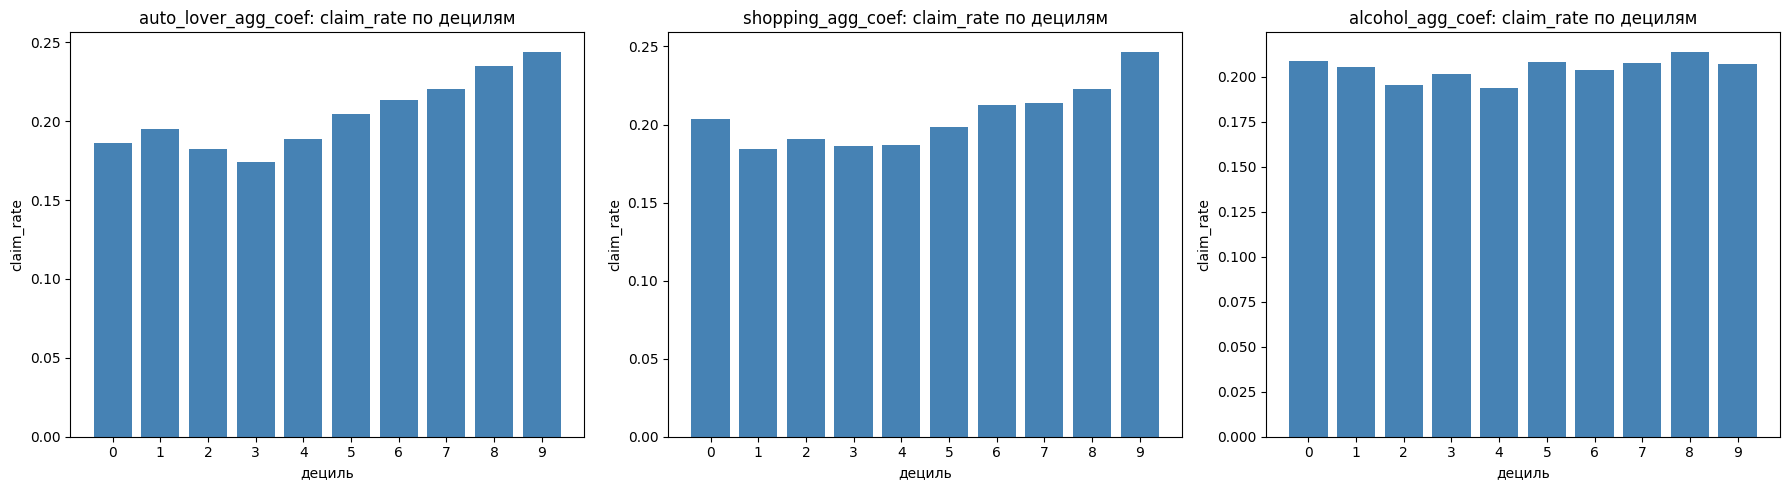

In [6]:
coef_cols = ['auto_lover_agg_coef', 'shopping_agg_coef', 'alcohol_agg_coef']
fig, axes = plt.subplots(1, len(coef_cols), figsize=(6 * len(coef_cols), 5))

for ax, col in zip(axes, coef_cols):
    bins = pd.qcut(result[col].rank(method='first'), q=10, labels=False)
    analysis = (
        pd.DataFrame({'bin': bins, 'target': casco_hashtags_full[TARGET_COL]})
        .groupby('bin')['target']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
    )
    ax.bar(analysis.index.astype(str), analysis['claim_rate'], color='steelblue')
    ax.set_title(f'{col}: claim_rate по децилям')
    ax.set_xlabel('дециль')
    ax.set_ylabel('claim_rate')

plt.tight_layout()
plt.show()